# Clustering: Cardiovascular severity
Clustering to identify patients with different levels of cardiac impairment

Before clustering, we import the dependency libraries: 

In [128]:
!pip install pandas scikit-learn

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from collections import Counter
from pathlib import Path

And load the patient profile dataset 

In [130]:
notebook_dir = Path().resolve()
FEATURE_PATH = notebook_dir.parents[1]  / "1" / "Features" 
PATIENT_PROFILES_NAME = "patient_profiles.csv"

df = pd.read_csv(FEATURE_PATH / PATIENT_PROFILES_NAME)

## Feature selection for  cardiovascular severity clustering

We take from patient profiles features all those which rely on cardiovascular severity

In [133]:
features_severity = [
    # CORE
    #'heart_failure_severity_score',     
    #'cad_severity_score',
    'cardiac_remodeling_score',
    'valvular_disease_score',
    #'ct_complications_score',
    #'ecg_abnormality_score',
    'hemodynamic_instability_score',
    # OUTPUT
    'oxygen_saturation', 
    # RENAL               
    'creat_max',
    # UTILIZATION                      
    'total_procedures',                 
    'procedures_days_span',
]


In [134]:
# Extract data subset
df_severity = df[['subject_id'] + features_severity].copy()

In [135]:
# Handle missing values
df_severity_clean = df_severity.dropna(subset=features_severity)
print(f"\nUsable patients: {len(df_severity_clean)} / {len(df_severity)}")


Usable patients: 4694 / 4694


In [136]:
# Prepare data for clustering
X_severity = df_severity_clean[features_severity]


## Data normalization

In [137]:
X_severity.head()

,cardiac_remodeling_score,valvular_disease_score,hemodynamic_instability_score,oxygen_saturation,creat_max,total_procedures,procedures_days_span
0,2.0,3.0,0.0,100.0,1.194,2.079,0.000
1,2.4,2.2,1.0,96.0,0.693,1.099,0.000
2,0.5,1.3,0.0,96.2,0.788,2.197,2.708
3,0.0,0.0,0.0,98.0,0.693,0.000,0.000
4,2.0,3.0,0.0,99.0,0.693,1.099,0.000


In [138]:
binary_cols = []
continuous_cols = []

for col in X_severity.columns:
    unique_vals = X_severity[col].nunique()
    if unique_vals <= 2:
        binary_cols.append(col)
    else:
        continuous_cols.append(col)

print(f"\nBinary features: {len(binary_cols)}")
print(binary_cols[:10])
print(f"\nContinuous features: {len(continuous_cols)}")
print(continuous_cols[:10])



Binary features: 0
[]

Continuous features: 7
['cardiac_remodeling_score', 'valvular_disease_score', 'hemodynamic_instability_score', 'oxygen_saturation', 'creat_max', 'total_procedures', 'procedures_days_span']


We use `RobustScaler` from sklearn to normalize contnuous features (Z-score normalization)

In [139]:
scaler = StandardScaler()
X_severity_normalized = scaler.fit_transform(X_severity)
X_severity_normalized = pd.DataFrame(
    X_severity_normalized, 
    columns=features_severity, 
    index=df_severity_clean.index
)


In [140]:
X_severity_normalized.head()

,cardiac_remodeling_score,valvular_disease_score,hemodynamic_instability_score,oxygen_saturation,creat_max,total_procedures,procedures_days_span
0,-0.244861,0.870190,-0.249728,1.368704,0.703941,1.033527,-0.455299
1,-0.003357,0.131852,1.617169,-0.353354,-0.581312,-0.004116,-0.455299
2,-1.150501,-0.698778,-0.249728,-0.267251,-0.337601,1.158468,3.241574
3,-1.452381,-1.898578,-0.249728,0.507675,-0.581312,-1.167759,-0.455299
4,-0.244861,0.870190,-0.249728,0.938189,-0.581312,-0.004116,-0.455299


## K-means clustering 

In [141]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_severity_normalized)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_severity_normalized, kmeans.labels_))


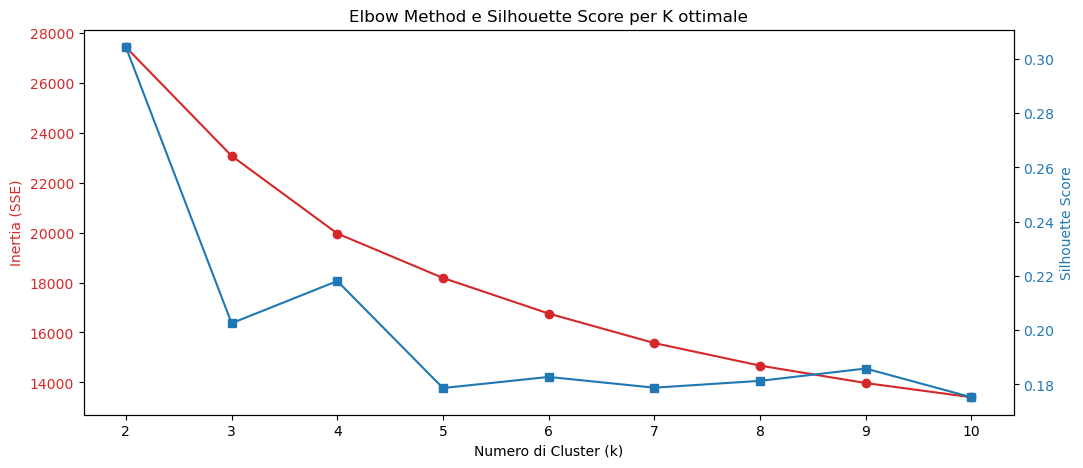

In [142]:
# Plot Elbow Method e Silhouette
fig, ax1 = plt.subplots(figsize=(12, 5))

color = 'tab:red'
ax1.set_xlabel('Numero di Cluster (k)')
ax1.set_ylabel('Inertia (SSE)', color=color)
ax1.plot(K_range, inertia, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(K_range, silhouette_scores, marker='s', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Elbow Method e Silhouette Score per K ottimale')
plt.show()

In [155]:
optimal_k = 2

### Training with optimal K

In [156]:
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10, max_iter=300)
cluster_labels = kmeans_final.fit_predict(X_severity_normalized)

In [157]:
# Add labels to dataframe
df_severity_clean['cluster'] = cluster_labels

### Clusters distribution and characterization

In [158]:
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
print("\nCluster sizes:")
for cluster_id, count in cluster_counts.items():
    percentage = (count / len(cluster_labels)) * 100
    print(f"  Cluster {cluster_id}: {count:4d} patients ({percentage:5.1f}%)")


Cluster sizes:
  Cluster 0:  911 patients ( 19.4%)
  Cluster 1: 3783 patients ( 80.6%)


In [159]:
df_severity_clean['cluster'] = kmeans.labels_
profile = df_severity_clean.groupby('cluster')[features_severity].mean()
print(profile.T) 

cluster                                0          1          2          3  \
cardiac_remodeling_score        2.822768   1.796955   4.035424   2.990270   
valvular_disease_score          2.379241   2.122046   2.670111   2.273514   
hemodynamic_instability_score   0.076339   0.013398   0.050000   2.464865   
oxygen_saturation              92.724330  97.802071  97.291697  96.491892   
creat_max                       0.868842   0.739196   0.973921   1.002178   
total_procedures                0.882663   1.658323   0.181600   1.750297   
procedures_days_span            0.081092   0.103525   0.000000   0.838524   

cluster                                4          5          6          7  \
cardiac_remodeling_score        2.985965   1.463827   0.408319   3.477397   
valvular_disease_score          2.409023   2.157901   0.019800   2.529452   
hemodynamic_instability_score   0.025063   0.040494   0.043927   0.102740   
oxygen_saturation              96.804762  97.397531  97.191681  96.636301  

#### PCA visualization

In [160]:
from sklearn.decomposition import PCA


pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_severity_normalized)


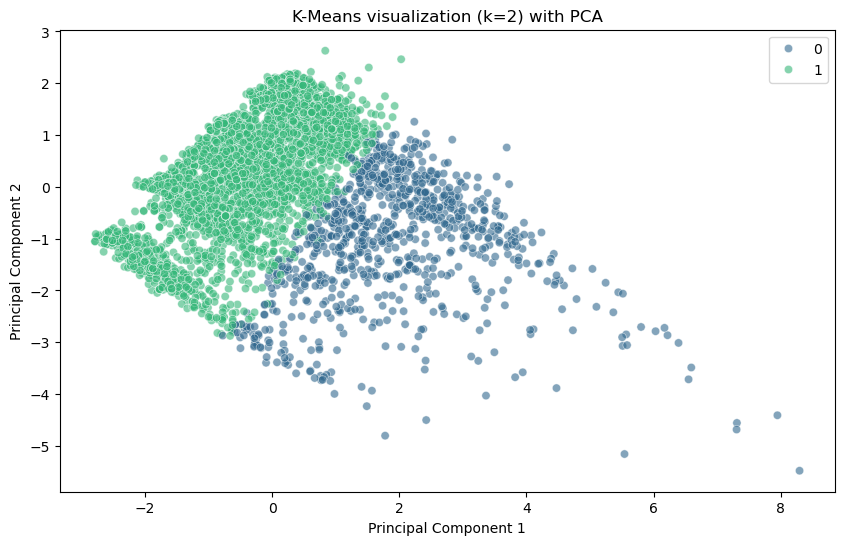

In [161]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=cluster_labels, palette='viridis', alpha=0.6)
plt.title(f'K-Means visualization (k={optimal_k}) with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

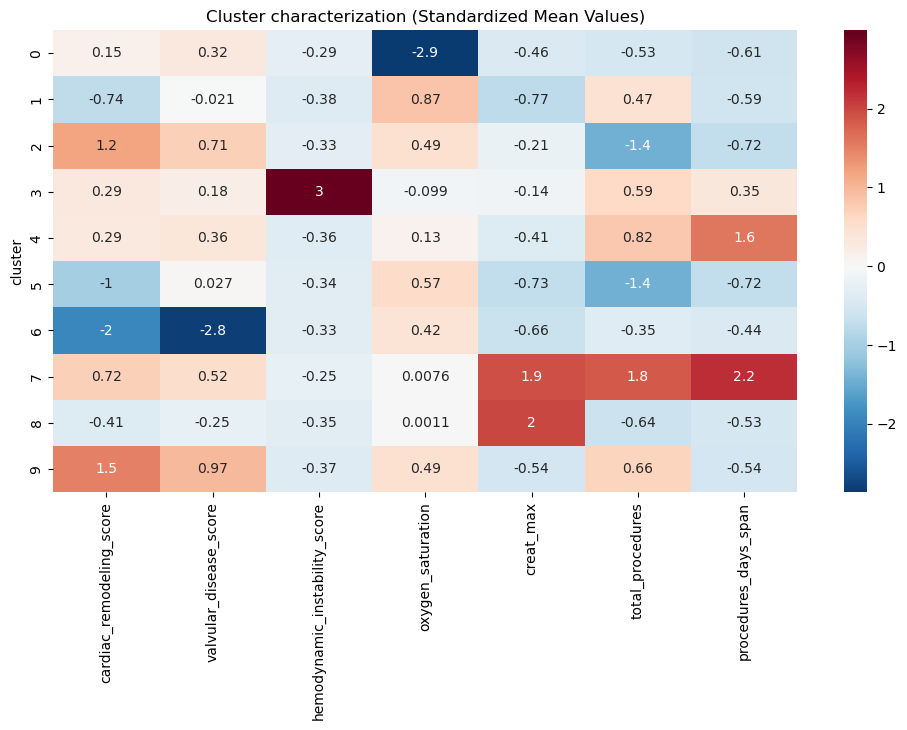

In [162]:
cluster_means = df_severity_clean.groupby('cluster')[features_severity].mean()
scaler_means = StandardScaler()
cluster_means_scaled = pd.DataFrame(scaler_means.fit_transform(cluster_means), 
                                    columns=features_severity, index=cluster_means.index)

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_means_scaled, annot=True, cmap='RdBu_r', center=0)
plt.title('Cluster characterization (Standardized Mean Values)')
plt.show()

In [163]:
# Ottieni i loadings delle prime due componenti
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=features_severity
)

# Ordina per valore assoluto per trovare le feature più influenti
loadings_sorted = loadings.abs().sort_values('PC1', ascending=False)
print(loadings_sorted.head(10))


                                    PC1       PC2
procedures_days_span           0.488823  0.449610
cardiac_remodeling_score       0.478993  0.491376
total_procedures               0.444357  0.434240
valvular_disease_score         0.411185  0.571130
creat_max                      0.330976  0.095990
hemodynamic_instability_score  0.214514  0.158614
oxygen_saturation              0.097622  0.085287


In [164]:
# Identifica outliers in PC1 e PC2
threshold = 3  # Deviazioni standard
pc1_mean, pc1_std = X_pca[:, 0].mean(), X_pca[:, 0].std()
pc2_mean, pc2_std = X_pca[:, 1].mean(), X_pca[:, 1].std()

outliers_mask = (
    (np.abs(X_pca[:, 0] - pc1_mean) > threshold * pc1_std) |
    (np.abs(X_pca[:, 1] - pc2_mean) > threshold * pc2_std)
)

# Estrai i pazienti outliers
outliers_indices = np.where(outliers_mask)[0]
outliers_data = df_severity_clean.iloc[outliers_indices]


In [165]:

outliers_stats = X_severity.iloc[outliers_indices].describe()
normal_stats = X_severity.iloc[~outliers_mask].describe()

comparison = pd.DataFrame({
    'outliers_mean': outliers_stats.loc['mean'],
    'normal_mean': normal_stats.loc['mean'],
    'diff': outliers_stats.loc['mean'] - normal_stats.loc['mean']
}).sort_values('diff', key=abs, ascending=False)

print(comparison.head(10))


                               outliers_mean  normal_mean      diff
procedures_days_span                2.993650     0.299069  2.694581
total_procedures                    3.368000     1.073559  2.294441
hemodynamic_instability_score       1.216667     0.119745  1.096921
creat_max                           1.641433     0.910253  0.731180
cardiac_remodeling_score            2.993333     2.397950  0.595383
oxygen_saturation                  96.673333    96.822680 -0.149347
valvular_disease_score              2.016667     2.057661 -0.040994


In [166]:
# Identifica i pazienti outliers più estremi
extreme_outliers = outliers_data.nlargest(10, 'heart_failure_severity_score')

# Analizza il loro profilo completo
print(extreme_outliers[features_severity])

# Controlla se appartengono a un cluster specifico
print(extreme_outliers['cluster'].value_counts())

KeyError: 'heart_failure_severity_score'

## DBSCAN

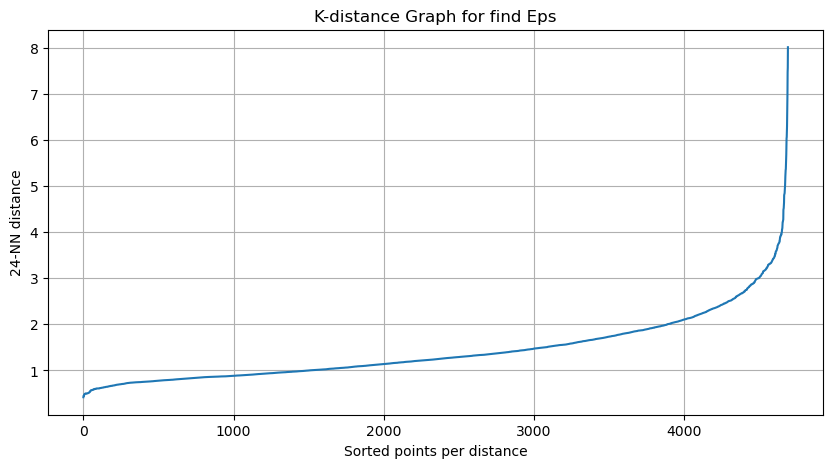

In [ ]:
# Calcolo della distanza k-NN per stimare eps
k = 24 # min_samples ipotetico
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_severity_normalized)
distances, indices = neighbors_fit.kneighbors(X_severity_normalized)

distances = np.sort(distances[:, k-1], axis=0)
plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('K-distance Graph for find Eps')
plt.xlabel('Sorted points per distance')
plt.ylabel(f'{k}-NN distance')
plt.grid(True)
plt.show()


In [ ]:
# Imposta i parametri in base al grafico sopra
EPSILON = 3.5  # <-- DA TUNARE in base al grafico
MIN_SAMPLES = 24

dbscan = DBSCAN(eps=EPSILON, min_samples=MIN_SAMPLES)
clusters_dbscan = dbscan.fit_predict(X_scaled)

# Statistiche
n_clusters_ = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
n_noise_ = list(clusters_dbscan).count(-1)

print(f'Numero di cluster stimati: {n_clusters_}')
print(f'Numero di punti di rumore (outliers): {n_noise_}')

# Visualizzazione PCA
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters_dbscan, palette='tab10', alpha=0.6)
plt.title(f'DBSCAN (eps={EPSILON}, min_samples={MIN_SAMPLES})')
plt.show()


NameError: name 'X_scaled' is not defined